In [1]:
#Import thư viện
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
df = pd.read_csv("titanic_disaster.csv")



In [ ]:
#PHAN1
#Cau1
def load_data(path):
    df = pd.read_csv(path)
    return df

train = load_data("titanic_disaster.csv")
train.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


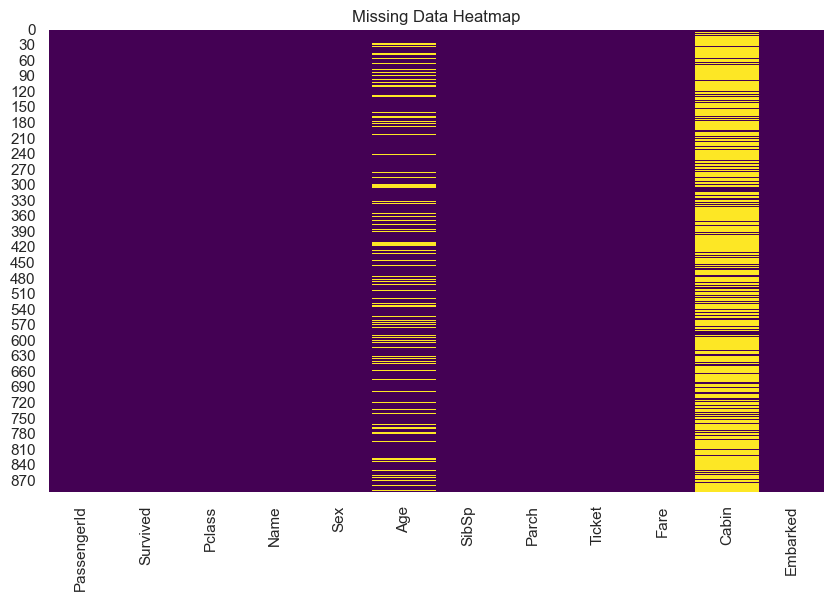

In [4]:
#Cau2
# Thống kê dữ liệu thiếu
train.isnull().sum()

# Heatmap dữ liệu thiếu
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()


In [ ]:
#CHO NHẬN XÉT
#Age bị thiếu khá nhiều dữ liệu, cần xử lý trước khi phân tích.
#Cabin thiếu phần lớn thông tin, chỉ nên khai thác ở mức tổng quát.
#Embarked chỉ thiếu rất ít dữ liệu, hầu như không ảnh hưởng đến phân tích.
#=> Dữ liệu thiếu chủ yếu tập trung ở Age và Cabin.


In [9]:
#Cau3
df[['secondName', 'firstName']] = df['Name'].str.split(',', expand=True)

df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()

df.drop(columns=['Name'], inplace=True)

df[['firstName', 'secondName']].head()


,firstName,secondName
0,Mr. Owen Harris,Braund
1,Mrs. John Bradley (Florence Briggs Thayer),Cumings
2,Miss. Laina,Heikkinen
3,Mrs. Jacques Heath (Lily May Peel),Futrelle
4,Mr. William Henry,Allen


In [10]:
#Cau4
df['Sex'] = df['Sex'].replace({
    'male': 'M',
    'female': 'F'
})

df['Sex'].value_counts()



Sex
M    577
F    314
Name: count, dtype: int64

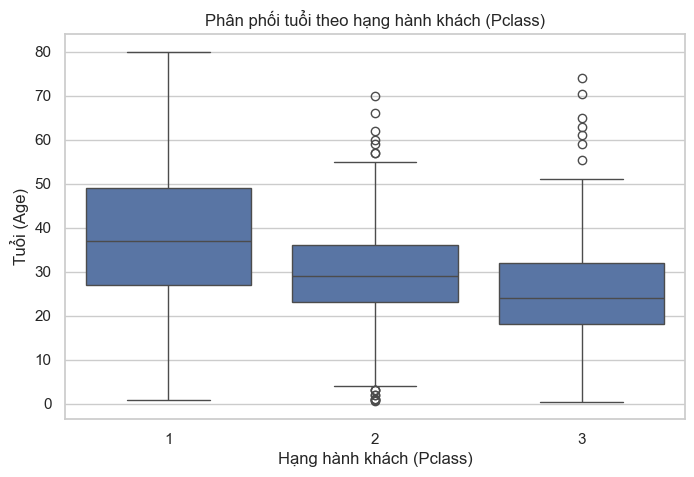

In [11]:
#Cau5
#a
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title("Phân phối tuổi theo hạng hành khách (Pclass)")
plt.xlabel("Hạng hành khách (Pclass)")
plt.ylabel("Tuổi (Age)")
plt.show()

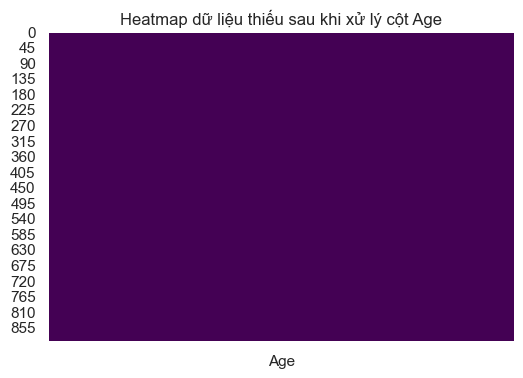

In [12]:
#b
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)
df[['Age', 'Pclass']].head(10)
df['Age'].isnull().sum()
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Age']].isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap dữ liệu thiếu sau khi xử lý cột Age")
plt.show()


In [8]:
#Cau6
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

df['Agegroup'] = df['Age'].apply(age_group)
df['Agegroup'].value_counts()



Agegroup
Adult      553
Unknown    177
Teen        70
Kid         69
Older       22
Name: count, dtype: int64

In [20]:
#Cau7
df['namePrefix'] = df['firstName'].str.extract(
    '(Mr|Mrs|Miss|Master)',
    expand=False
)

df['namePrefix'] = df['namePrefix'].fillna('Other')

df[['firstName', 'namePrefix']].head(10)
df['namePrefix'].value_counts()



namePrefix
Mr        645
Miss      182
Master     40
Other      24
Name: count, dtype: int64

In [2]:
# Câu 8: Tạo biến familySize
# familySize = 1 + SibSp + Parch

df['familySize'] = 1 + df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'familySize']].head(10)
df['familySize'].value_counts().sort_index()


familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [ ]:
#Cau9
df['Alone'] = df['familySize'].apply(
    lambda x: 1 if x == 1 else 0
)
df[['familySize', 'Alone']].head(10)
df['Alone'].value_counts()


Alone
1    537
0    354
Name: count, dtype: int64

In [ ]:
#Cau10

df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].str[0]
df[['Cabin', 'typeCabin']].head(10)
df['typeCabin'].value_counts()


typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

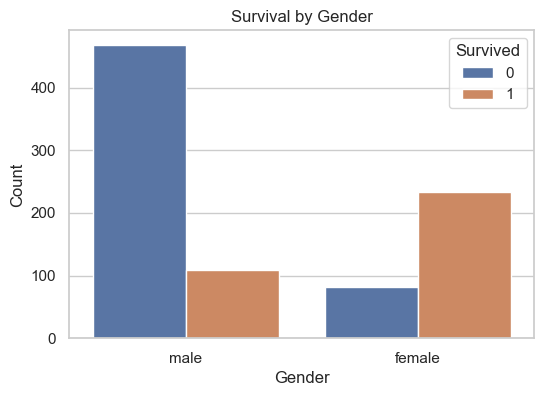

In [5]:
#PHAN2
#Cau12
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


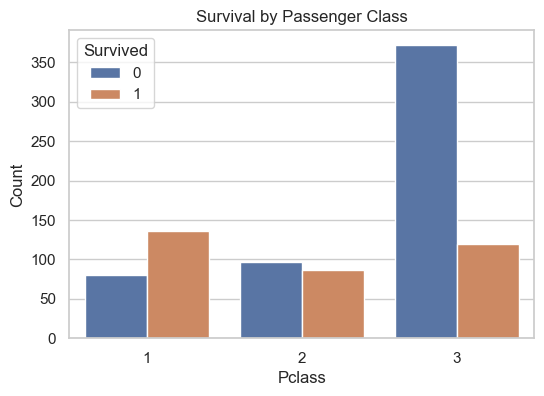

In [6]:
#Cau13
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

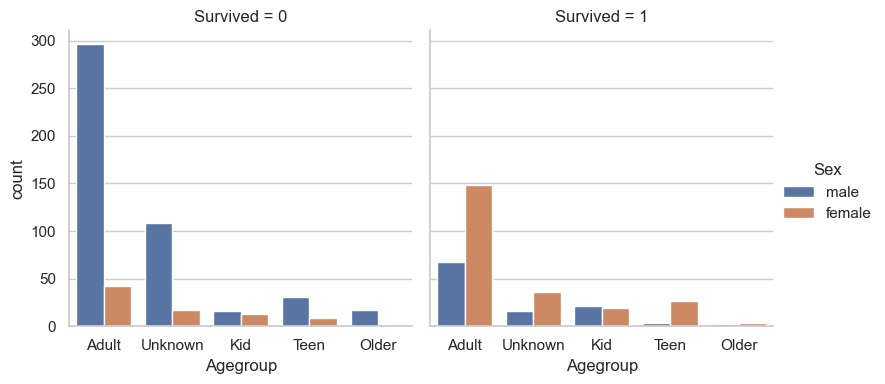

In [10]:
#Cau14
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

df['Agegroup'] = df['Age'].apply(age_group)

sns.catplot(
    data=df,
    x='Agegroup',
    hue='Sex',
    col='Survived',
    kind='count',
    height=4,
    aspect=1
)

plt.show()


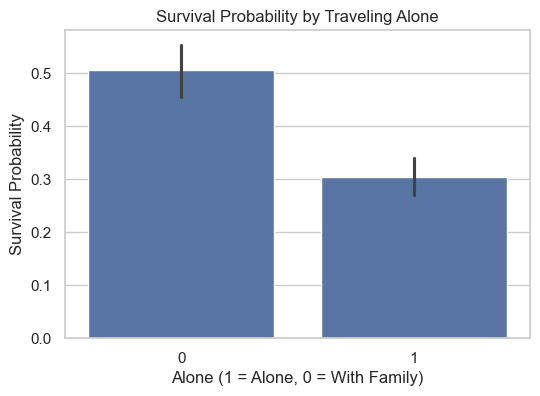

In [11]:
#Cau15
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Alone', y='Survived')
plt.title('Survival Probability by Traveling Alone')
plt.xlabel('Alone (1 = Alone, 0 = With Family)')
plt.ylabel('Survival Probability')
plt.show()


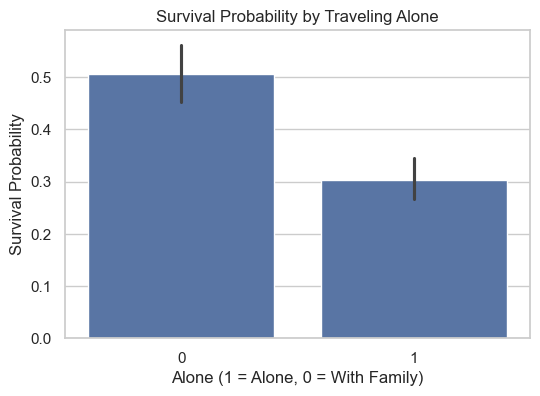

In [12]:
#Cau16
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Alone', y='Survived')
plt.title('Survival Probability by Traveling Alone')
plt.xlabel('Alone (1 = Alone, 0 = With Family)')
plt.ylabel('Survival Probability')
plt.show()


In [ ]:
#Cau17
sns.catplot(
    data=df,
    x='Embarked',
    hue='Survived',
    col='Pclass',
    kind='count',
    height=4,
    aspect=1
)

plt.show()
